<a href="https://colab.research.google.com/github/latentfield/EV-Price-Prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# import platform
# system_os = platform.system()
# if system_os == 'Darwin':
#     plt.rcParams['font.famlly'] = 'Apple SD Gothic Neo'
# elif system_os == 'Windows':
#     plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# 2. Exploratory Data Analysis (EDA)

In [6]:
data = pd.read_csv('train.csv')
data

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
data.columns

Index(['ID', '제조사', '모델', '차량상태', '배터리용량', '구동방식', '주행거리(km)', '보증기간(년)',
       '사고이력', '연식(년)', '가격(백만원)'],
      dtype='str')

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
배터리용량,4786.0,69.397187,15.283635,46.0,56.359,68.125,78.227,99.80
주행거리(km),7497.0,44287.979458,55204.064386,3.0,5465.000,17331.000,61252.000,199827.00
보증기간(년),7497.0,4.960918,3.155342,0.0,2.000,5.000,8.000,10.00
연식(년),7497.0,0.222489,0.569232,0.0,0.000,0.000,0.000,2.00
가격(백만원),7497.0,62.331949,36.646759,9.0,34.390,56.000,80.050,161.09


# 결측치 확인

In [ ]:
data.isna().sum()

ID             0
제조사            0
모델             0
차량상태           0
배터리용량       2711
구동방식           0
주행거리(km)       0
보증기간(년)        0
사고이력           0
연식(년)          0
가격(백만원)        0
dtype: int64

# 결측치 처리를 위한 배터리용량 칼럼 분석

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

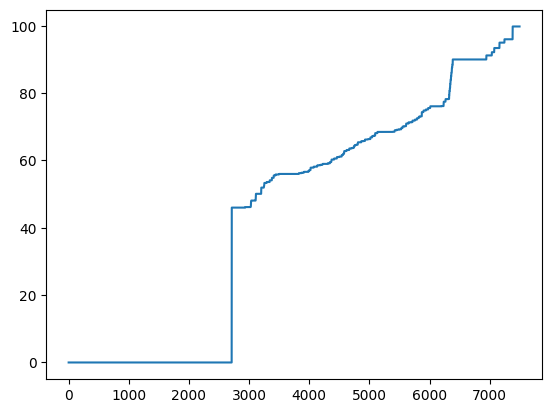

In [ ]:
plt.plot(sorted(data['배터리용량'].fillna(0).tolist()))

In [ ]:
data[data.describe().T.index].fillna(0).corr()

* 배터리용량과 numerical 칼럼들의 상관관계는 약하다고 판단.

In [ ]:
for idx, column_key in enumerate(['제조사', '차량상태', '구동방식', '사고이력', '연식(년)', '보증기간(년)']):
    for key in data[column_key].unique().tolist():
        plt.bar(key, data[data[column_key] == key]['배터리용량'].mean())
        plt.axhline(y=data['배터리용량'].mean(), color ='red')

    plt.axhline(y=data['배터리용량'].mean(), color='red')
    plt.title(column_key)
    plt.show()

배터리용량은

1. 보증기간이 7년 이상이면 유의미하게 길다.
2. brand-new일 경우 배터리용량이 크다.

In [ ]:
display(data[data['차량상태']=='Brand New'].describe().T)
display(data[data['차량상태']!='Brand New'].describe().T)

In [ ]:
print(data[data['차량상태']=='Brand New']['보증기간(년)'].mean())
print(data[data['차량상태']!='Brand New']['보증기간(년)'].mean())

In [ ]:
plt.plot(sorted(data[data['차량상태']=='Brand New']['보증기간(년)'].tolist()), label='Brand New')
plt.plot(sorted(data[data['차량상태']!='Brand New']['보증기간(년)'].tolist()), label='Not Brand New')
plt.legend(['Brand New', 'Not Brand New'])
plt.show()


Brand-new인 차량 대부분이 보증 기간이 7년 이상이다!

# 배터리 용량 결측치 처리 결론:
보증기간 7년 이상 / 7년 미만을 기준으로
각각의 평균값으로 처리함.

# Data Process

In [ ]:
train_data = pd.read_csv('train.csv').drop(columns=['ID'])
submit_test_data = pd.read_csv('test.csv').drop(columns=['ID'])


In [ ]:
numeric_cols = ['주행거리(km)', '보증기간(년)', '연식(년)']
for col in numeric_cols:
    train_data[col].fillna(train_data[col].median(), inplace=True)
    submit_test_data[col].fillna(submit_test_data[col].median(), inplace=True)

# Feature Engineering: Calculate 'Mileage per Year'
# Physics/Domain Intuition: Average yearly mileage is a strong proxy for battery degradation.
current_year = 2025
train_data['연간_주행거리(km)'] = train_data['주행거리(km)'] / (current_year - train_data['연식(년)'] + 1)
submit_test_data['연간_주행거리(km)'] = submit_test_data['주행거리(km)'] / (current_year - submit_test_data['연식(년)'] + 1)

categorical_cols = ['제조사', '차량상태', '구동방식', '사고이력']
for col in categorical_cols:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    submit_test_data[col].fillna(submit_test_data[col].mode()[0], inplace=True)

train_data['배터리용량'].fillna(-1, inplace=True)
submit_test_data['배터리용량'].fillna(-1, inplace=True)

upper7_train = train_data[train_data['보증기간(년)']>=7]['배터리용량'].mean()
lower7_train = train_data[train_data['보증기간(년)']<7]['배터리용량'].mean()

upper7_test = submit_test_data[submit_test_data['보증기간(년)']>=7]['배터리용량'].mean()
lower7_test = submit_test_data[submit_test_data['보증기간(년)']>=7]['배터리용량'].mean()

def fill_battery(row, upper7, lower7):
    if row['배터리용량'] == -1:
        return upper7 if row['보증기간(년)'] >= 7 else lower7
    return row['배터리용량']

train_data['배터리용량'] = train_data.apply(lambda row: fill_battery(row, upper7_train, lower7_train), axis=1)
submit_test_data['배터리용량'] = submit_test_data.apply(lambda row: fill_battery(row, upper7_test, lower7_test), axis=1)

In [ ]:
encoder = LabelEncoder()
train_data['모델'] = encoder.fit_transform(train_data['모델'].astype(str))  # 문자열 → 숫자로 변환
submit_test_data['모델'] = encoder.transform(submit_test_data['모델'].astype(str))

for col in categorical_cols:
    train_data[col] = encoder.fit_transform(train_data[col].astype(str))
    submit_test_data[col] = encoder.transform(submit_test_data[col].astype(str))
    train_data[col] = encoder.fit_transform(train_data[col])
    submit_test_data[col] = encoder.transform(submit_test_data[col])

In [ ]:
X = train_data.drop(columns=['가격(백만원)'])
y = train_data['가격(백만원)']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.dtypes)

# 모델 학습

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
print(f"Random Forest RMSE: {rmse_rf}")

In [ ]:
print("실제 가격 (y_valid) 분포:")
print(y_valid.describe())

print("\n예측 가격 (y_pred) 분포:")
print(pd.Series(y_pred_rf).describe())

print(f"\nValidation RMSE: {rmse_rf:.4f} (백만원 단위)")

# 결과물 출력

In [ ]:
final_pred = rf_model.predict(submit_test_data)

submission = pd.DataFrame({
    'ID': pd.read_csv('test.csv')['ID'],
    '가격(백만원)': final_pred
})

submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' successfully generated")